In [1]:
from src.data import CICIDS2017, N_BaIoT, CIC_UNSW, balanced_sample, TabPFNDataGenerator
from src.models import TabNetModel, TabPFNModel, TabICLModel, TabSTARModel
from src.models import PreConfigured_LogisticRegression, PreConfigured_RandomForest, PreConfigured_LinearSVC, PreConfigured_DecisionTree, PreConfigured_KNeighbors
from src.pipelines import TTPipeline, plot_accuracies

c:\Users\pablo\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import logging

for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

### Data

In [ ]:
dataset = CICIDS2017(pca=False, classes_mapping=False)
# dataset = N_BaIoT(pca=False, classes_mapping=False)
# dataset = CIC_UNSW(pca=False)
dataset.load()
# dataset.balance_(n=200, category_col="Label")
train, test = dataset.train_test_split(test_size=0.3)
X_train = train.drop(columns=["Label"]).values
y_train = train["Label"].values
X_test = test.drop(columns=["Label"]).values
y_test = test["Label"].values

INFO: Loading dataset...
INFO: Collecting data from saved (c:\Users\pablo\OneDrive\Desktop\TFG\code\AI-for-IDS\data\N-BaIoT\processed\n_baiot_64_to_32_quantization(True)_classes_mapping(False)_pca(False).csv)
INFO: Done collecting data


### Models

#### Preparing

In [4]:
%%time
logreg = PreConfigured_LogisticRegression()
svc = PreConfigured_LinearSVC()
randomforest = PreConfigured_RandomForest()
kneighbors = PreConfigured_KNeighbors()
decision_tree = PreConfigured_DecisionTree()
tabnet = TabNetModel(pretrain=True)
tabpfn = TabPFNModel()
tabicl = TabICLModel()
tabstar = TabSTARModel()

🖥️ Using device: cuda
CPU times: total: 31.2 ms
Wall time: 1.71 s


c:\Users\pablo\AppData\Local\Programs\Python\Python312\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


#### Training

##### Logistic Regression

In [ ]:
logreg_pl = TTPipeline(logreg)
logreg_pl.train(X_train, y_train, cv=5)
logreg_results = logreg_pl.evaluate(X_test, y_test)
logreg.save()

In [ ]:
print("Precision:", logreg_results["precision"])
print("Recall:", logreg_results["recall"])
print("F1-Score:", logreg_results["f1_score"])

##### Support Vector Machine

In [ ]:
svc_pl = TTPipeline(svc)
svc_pl.train(X_train, y_train, cv=5)
svc_results = svc_pl.evaluate(X_test, y_test)
svc.save()

In [ ]:
print("Precision:", svc_results["precision"])
print("Recall:", svc_results["recall"])
print("F1-Score:", svc_results["f1_score"])

##### Random Forest

In [ ]:
%%time
randomforest_pl = TTPipeline(randomforest)
randomforest_pl.train(X_train, y_train, cv=5)

In [ ]:
%%time
randomforest_results = randomforest_pl.evaluate(X_test, y_test)

In [ ]:
randomforest.save()

In [ ]:
print("Precision:", randomforest_results["precision"])
print("Recall:", randomforest_results["recall"])
print("F1-Score:", randomforest_results["f1_score"])

##### K-Neighbors

In [ ]:
%%time
kneighbors_pl = TTPipeline(kneighbors)
kneighbors_pl.train(X_train, y_train, cv=5)

In [ ]:
%%time
kneighbors_results = kneighbors_pl.evaluate(X_test, y_test)

In [ ]:
kneighbors.save()

In [ ]:
print("Precision:", kneighbors_results["precision"])
print("Recall:", kneighbors_results["recall"])
print("F1-Score:", kneighbors_results["f1_score"])

##### Decision Tree

In [ ]:
%%time
decision_tree_pl = TTPipeline(decision_tree)
decision_tree_pl.train(X_train, y_train, cv=5)

In [ ]:
%%time
decision_tree_results = decision_tree_pl.evaluate(X_test, y_test)

In [ ]:
%%time
decision_tree.save()

In [ ]:
print("Precision:", decision_tree_results["precision"])
print("Recall:", decision_tree_results["recall"])
print("F1-Score:", decision_tree_results["f1_score"])

##### TabNet

In [ ]:
%%time
tabnet_pl = TTPipeline(tabnet)
tabnet_pl.train(X_train, y_train, X_test, y_test, smote_augmentation=False)

In [ ]:
%%time
tabnet_results = tabnet_pl.evaluate(X_test, y_test)

In [ ]:
%%time
tabnet.save()

In [ ]:
print("Accuracy:", tabnet_results["accuracy"])
print("Precision:", tabnet_results["precision"])
print("Recall:", tabnet_results["recall"])
print("F1-Score:", tabnet_results["f1_score"])

In [ ]:
tabnet.plot_metrics()

##### TabPFN

In [ ]:
# Balance training samples
smaller_train = balanced_sample(train, "Label", 2000)
new_x = smaller_train.drop(columns=["Label"]).values
new_y = smaller_train["Label"].values

In [ ]:
# Augment samples
generator = TabPFNDataGenerator()
augmented_new_x, augmented_new_y = generator.generate(100, new_x, new_y, threshold=0.25)

In [ ]:
smaller_train["Label"].value_counts()

In [ ]:
%%time
tabpfn_pl = TTPipeline(tabpfn)
tabpfn_pl.train(new_x, new_y)

In [ ]:
%%time
tabpfn_results = tabpfn_pl.evaluate(X_test, y_test)
tabpfn.save()

In [ ]:
print("Accuracy:", tabpfn_results["accuracy"])
print("Precision:", tabpfn_results["precision"])
print("Recall:", tabpfn_results["recall"])
print("F1-Score:", tabpfn_results["f1_score"])

##### TabICL

In [ ]:
smaller_train = balanced_sample(train, "Label", 2000)
new_x = smaller_train.drop(columns=["Label"]).values
new_y = smaller_train["Label"].values

In [ ]:
%%time
tabicl_pl = TTPipeline(tabicl)
tabicl_pl.train(new_x, new_y)

In [ ]:
%%time
tabicl_results = tabicl_pl.evaluate(X_test, y_test)

In [ ]:
%%time
tabicl.save()

In [ ]:
print("Accuracy:", tabicl_results["accuracy"])
print("Precision:", tabicl_results["precision"])
print("Recall:", tabicl_results["recall"])
print("F1-Score:", tabicl_results["f1_score"])

##### TabSTAR

In [ ]:
smaller_train = balanced_sample(train, "Label", 4000)

In [ ]:
%%time
tabstar_pl = TTPipeline(tabstar)
tabstar_pl.train(smaller_train.drop(columns=["Label"]), smaller_train["Label"]) # for TabSTAR the DataFrame form is preferred, but can also work with NDArray

INFO: Fitting TabSTAR model...


🤩 Loading pretrained model version: alana89/TabSTAR


Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1 || Train 3.3366 || Val 3.0297 || Metric 0.5299 🥇


Epochs:   2%|▏         | 1/50 [00:10<08:54, 10.91s/it]

...

Epochs:  22%|██▏       | 11/50 [01:43<05:54,  9.10s/it]

Epoch 11 || Train 0.0004 || Val 0.0000 || Metric 1.0000 😓 [3/5 worse]


Epochs:  24%|██▍       | 12/50 [01:51<05:44,  9.07s/it]

Epoch 12 || Train 0.0004 || Val 0.0004 || Metric 1.0000 😓 [4/5 worse]


Epoch 13 || Train 0.0002 || Val 0.0000 || Metric 1.0000 😓 [5/5 worse]
🛑 Early stopping at epoch 13


INFO: TabSTAR predicting labels...
INFO: Starting batch prediction with batch size of 660... (Total of 660 samples to predict)
INFO: 660 samples predicted


CPU times: total: 2.89 s
Wall time: 2.29 s


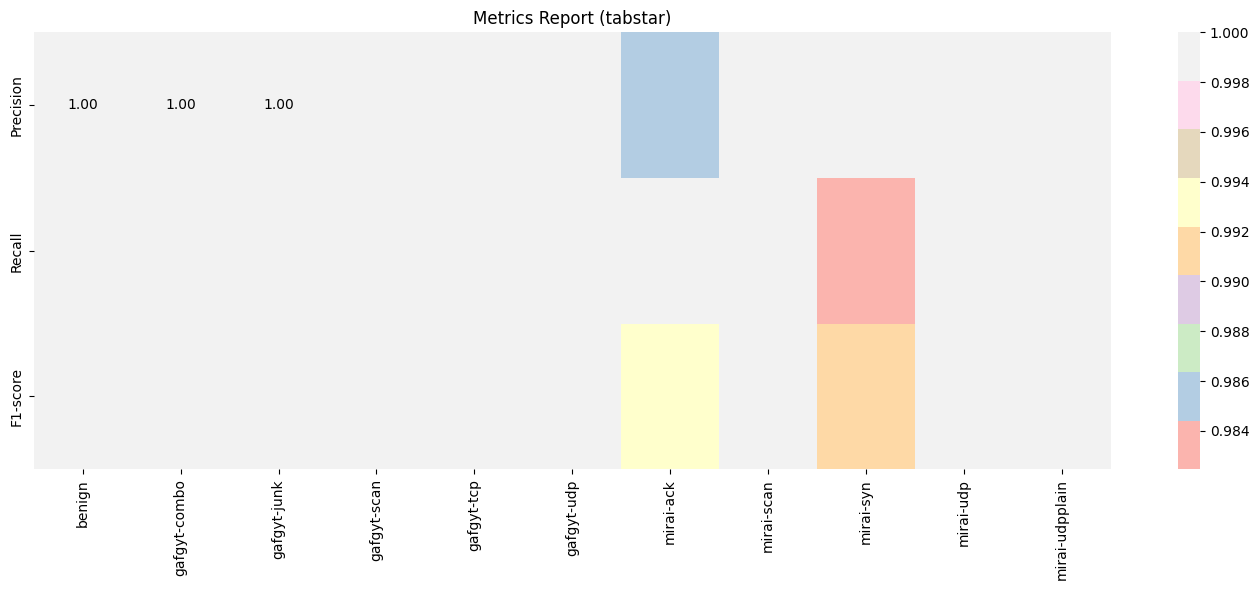

In [6]:
%%time
tabstar_results = tabstar_pl.evaluate(test, test["Label"])

In [8]:
print("Accuracy:", tabstar_results["accuracy"])
print("Precision:", tabstar_results["precision"])
print("Recall:", tabstar_results["recall"])
print("F1-Score:", tabstar_results["f1_score"])

Accuracy: 0.9984848484848485
Precision: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9850746268656716, 1.0, 1.0, 1.0, 1.0]
Recall: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9824561403508771, 1.0, 1.0]
F1-Score: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9924812030075187, 1.0, 0.9911504424778761, 1.0, 1.0]


#### From loaded

In [ ]:
logreg.name = "..."
logreg.load()
logreg_pl = TTPipeline(logreg)
logreg_results = logreg_pl.evaluate(X_test, y_test)

In [ ]:
svc.name = "..."
svc.load()
svc_pl = TTPipeline(svc)
svc_results = svc_pl.evaluate(X_test, y_test)
svc_results["accuracy"]

In [ ]:
randomforest.name = "..."
randomforest.load()
randomforest_pl = TTPipeline(randomforest)
randomforest_results = randomforest_pl.evaluate(X_test, y_test)
randomforest_results["accuracy"]

In [ ]:
kneighbors.name = "..."
kneighbors.load()
kneighbors_pl = TTPipeline(kneighbors)
kneighbors_results = kneighbors_pl.evaluate(X_test, y_test)

In [ ]:
decision_tree.name = "..."
decision_tree.load()
decision_tree_pl = TTPipeline(decision_tree)
decision_tree_results = decision_tree_pl.evaluate(X_test, y_test)

In [ ]:
tabnet.name = "..."
tabnet.load()
tabnet_pl = TTPipeline(tabnet)
tabnet_results = tabnet_pl.evaluate(X_test, y_test)

In [ ]:
tabpfn.load()
tabpfn_pl = TTPipeline(tabpfn)
tabpfn_results = tabpfn_pl.evaluate(X_test, y_test)
tabnet_results["accuracy"]

In [ ]:
tabicl.load()
tabicl_pl = TTPipeline(tabicl)
tabicl_results = tabpfn_pl.evaluate(X_test, y_test)
tabicl_results["accuracy"]

In [ ]:
tabstar.load()
tabstar_pl = TTPipeline(tabstar)
tabstar_results = tabpfn_pl.evaluate(X_test, y_test)
tabstar_results["accuracy"]

INFO: Loading model...


#### Performance

In [ ]:
accuracies = [
    # logreg_results["accuracy"],
    # svc_results["accuracy"],
    # randomforest_results["accuracy"],
    # kneighbors_results["accuracy"],
    # decision_tree_results["accuracy"],
    # tabnet_results["accuracy"],
    # tabpfn_results["accuracy"]
]

models_names = [
    # 'Logistic Regression',
    # 'SVM',
    # "Random Forest",
    # "KNeighbors",
    # "Decision Tree",
    # "TabNet",
    # "TabPFN"
]

In [ ]:
accuracy_plot = plot_accuracies(accuracies, models_names)